In [1]:
import os.path
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os.path
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# 한글 폰트 설정
from matplotlib import rc
plt.rc('font', family='Apple SD Gothic Neo')

In [12]:
df = pd.read_csv('../ch05/data/owid-covid-data.csv', encoding='cp949')
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [13]:
def get_covid_data_series(file_path):
    kor_df = pd.read_csv(file_path)
    kor_index_df = kor_df.set_index('date')
    return kor_index_df['total_cases']

kor_data = get_covid_data_series('../ch05/data/covid-kor.csv')
usa_data = get_covid_data_series('../ch05/data/covid-usa.csv')
index_data = kor_data.index

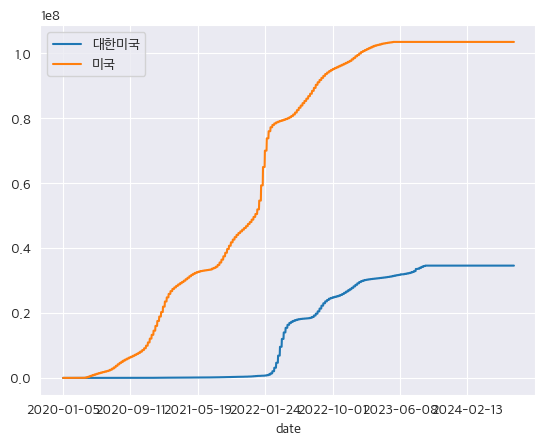

In [14]:
covid_df = pd.DataFrame(
    {
        '대한미국': kor_data,
        '미국': usa_data
    }, index=index_data
)
covid_df.plot.line()
plt.show()

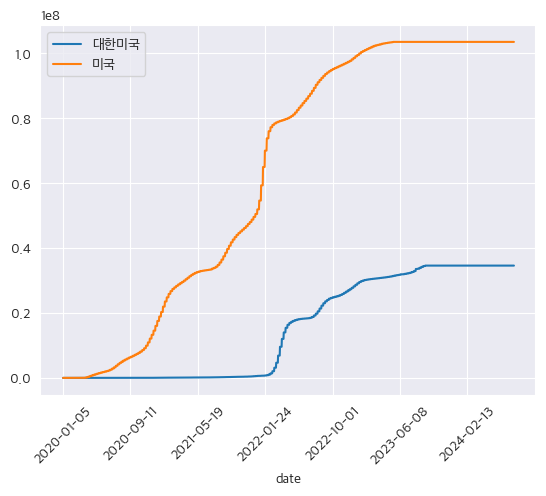

In [15]:
covid_df = pd.DataFrame(
    {
        '대한미국': kor_data,
        '미국': usa_data
    }, index=index_data
)
covid_df[:].plot.line(rot = 45)
plt.show()

In [64]:
# 인구수 가져오는 함수
def get_population(file_path):
    df = pd.read_csv(file_path)
    index_df = df.set_index('date')

    return index_df['population']['2020-01-05']

In [29]:
kor_population = get_population('../ch05/data/covid-kor.csv')
print('대한민국 인구수: ',kor_population)

대한민국 인구수:  51815808


In [30]:
usa_population = get_population('../ch05/data/covid-usa.csv')
print('미국 인구수: ',usa_population)

미국 인구수:  338289856


In [33]:
# 인구수 비율
rate = usa_population / kor_population
print('인구비율은: ',rate)
rate = round(usa_population / kor_population,2)
print('인구비율은: ',rate)

인구비율은:  6.528699812999153
인구비율은:  6.53


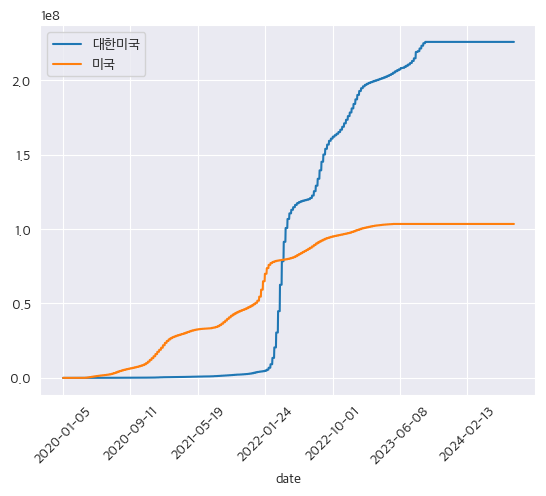

In [34]:
covid_df = pd.DataFrame(
    {
        '대한미국': kor_data * rate,
        '미국': usa_data
    }, index=index_data
)
covid_df[:].plot.line(rot = 45)
plt.show()

In [43]:
# 원본 데이터에서 데이터 뽑아내기
df = pd.read_csv('../ch05/data/owid-covid-data.csv', encoding='cp949')
df.head()

selected_col = ['iso_code', 'location', 'date', 'total_cases','population']
selected_df = df[selected_col]

select_date_index_df = selected_df.set_index('date')

covid_csv_file_path = '../ch05/data/common_covid.csv'
if os.path.isfile(covid_csv_file_path):
    os.remove(covid_csv_file_path)
select_date_index_df.to_csv(covid_csv_file_path,encoding='utf-8')

In [44]:
def get_covid_data(iso_code):
    file_path = '../ch05/data/common_covid.csv'

    df = pd.read_csv(file_path)
    filter_df = df[df.iso_code == iso_code]
    index_df = filter_df.set_index('date')

    return index_df['total_cases']

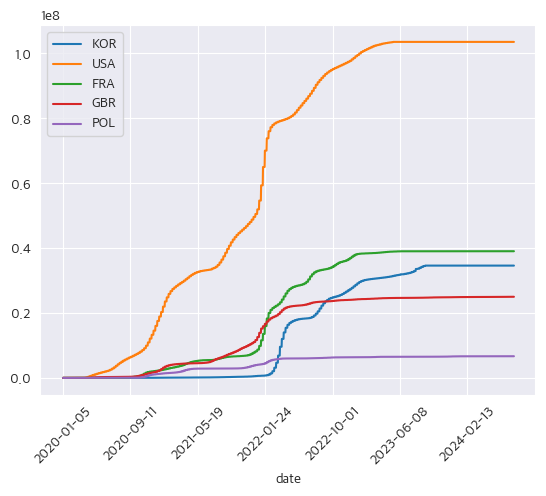

In [49]:
kor_data = get_covid_data('KOR')
usa_data = get_covid_data('USA')
fra_data = get_covid_data('FRA')
gbr_data = get_covid_data('GBR')
pol_data = get_covid_data('POL')
index_data = kor_data.index
# 인구 비율 가만해서 작성
data = {
    'KOR': kor_data,
    'USA': usa_data,
    'FRA': fra_data,
    'GBR': gbr_data,
    'POL': pol_data
}

covid_df = pd.DataFrame(data, index=index_data)
covid_df[:].plot.line(rot = 45)
plt.show()

In [81]:
def get_covid_data(iso_code):
    file_path = '../ch05/data/common_covid.csv'

    df = pd.read_csv(file_path)

    # 인구비율 기준 국가는 미국에 해당하는 인구수
    common_population_sr = df[df.iso_code == 'USA']['population']
    common_population = common_population_sr.iat[0]

    # 매개 변수로 넘어온 ios_code 국가의 인구수
    cur_population_rs = df[df.iso_code == iso_code]['population']
    cur_population = cur_population_rs.iat[0]

    rate = round(common_population/cur_population,2)

    filter_df = df[df.iso_code == iso_code]
    filter_index_df = filter_df.set_index('date')

    return filter_index_df['total_cases'] * rate

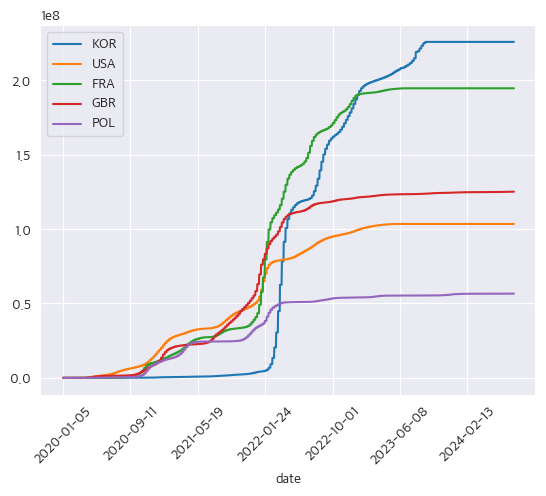

In [82]:
kor_data = get_covid_data('KOR')
usa_data = get_covid_data('USA')
fra_data = get_covid_data('FRA')
gbr_data = get_covid_data('GBR')
pol_data = get_covid_data('POL')
index_data = kor_data.index
# 인구 비율 가만해서 작성
data = {
    'KOR': kor_data,
    'USA': usa_data,
    'FRA': fra_data,
    'GBR': gbr_data,
    'POL': pol_data
}

covid_df = pd.DataFrame(data, index=index_data)
covid_df[:].plot.line(rot = 45)
plt.show()